<a href="https://colab.research.google.com/github/sanjanasrinivas22/6thSem-ML-Lab/blob/main/1BM23CS301_Lab_7_RandomForest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Best Trees = 10
Accuracy = 1.0


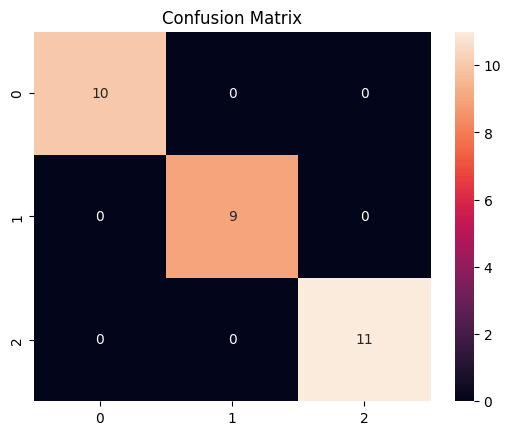

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

df = pd.read_csv("iris.csv")

X = df.iloc[:, :-1]
y = df.iloc[:, -1]

le = LabelEncoder()
y = le.fit_transform(y)

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

best_score = 0
best_tree = 0

for n in range(10,101,10):
    model = RandomForestClassifier(n_estimators=n,random_state=42)
    model.fit(X_train,y_train)
    pred = model.predict(X_test)
    score = accuracy_score(y_test,pred)

    if score > best_score:
        best_score = score
        best_tree = n

print("Best Trees =",best_tree)
print("Accuracy =",best_score)

model = RandomForestClassifier(n_estimators=best_tree)
model.fit(X_train,y_train)
pred = model.predict(X_test)

cm = confusion_matrix(y_test,pred)

sns.heatmap(cm,annot=True,fmt='d')
plt.title("Confusion Matrix")
plt.show()